In [9]:
#!/usr/bin/env python
# coding: utf-8

# Our quantifications match the visualization -- subsetting to the test
# conditions of interest in a given fold. Full feature space only.

# ============================================================================
# BLOCK 1 -- packages, data loading, functions, and metric calculation
#   Produces the three result frames consumed by BLOCK 2:
#       emd_loss_res    (Metric 1: EMD)
#       rank_loss_res   (Metric 2: rank)
#       cos_distances   (Metric 3: geometry / cosine residual, per condition)
# ============================================================================

import warnings

warnings.resetwarnings()
warnings.filterwarnings("ignore", category=FutureWarning,
                        message=r".*__version__ is deprecated.*")
warnings.filterwarnings("ignore", category=UserWarning,
                        message=r"Observation names are not unique.*")
warnings.filterwarnings("ignore", module=r"scanpy(\..*)?$")
warnings.filterwarnings("ignore", module=r"anndata(\..*)?$")
warnings.filterwarnings("ignore", message="Observation names are not unique.*")
warnings.filterwarnings("ignore", message="`__version__` is deprecated.*")
warnings.filterwarnings("ignore", category=FutureWarning, module="scanpy")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=ImportWarning)

from anndata._warnings import ImplicitModificationWarning
warnings.filterwarnings("ignore", category=ImplicitModificationWarning)


import os
import sys
from collections import defaultdict
import itertools

from tqdm import trange

import seaborn as sns 
import matplotlib.pyplot as plt


import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine as cosine_distance

sys.path.insert(1, '../../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../../.')
from notebook_utils import get_split

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.metrics import distances

In [4]:
# ---- config -----------------------------------------------------------------
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


# ---- data -------------------------------------------------------------------
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label,
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

merged_adatas = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
)
merged_adatas_rand = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_rand_predictions.pickle'.format(author))
)
mod_types = {
    'actual': merged_adatas,
    'random': merged_adatas_rand,
}

n_folds = 5

In [5]:
# =============================================================================
# Functions
# =============================================================================

def pert_centroids(adata):
    """Mean (centroid) feature vector per perturbation, full feature space."""
    X = adata.to_df()
    X[pert_col] = adata.obs[pert_col].astype(str).tolist()
    X = X.groupby(pert_col).mean()
    return X


def get_cos_dist(fold, tf_adata_merged):
    """
    Systema (https://www.nature.com/articles/s41587-025-02777-8) cosine distance,
    quantifying the condition space relative to the random baseline. Requires
    controls, so this uses the full feature space. Returns one row per
    perturbation (predicted vs actual cosine distance to the global pert axis).
    """
    distances_ = defaultdict(list)

    split = get_split(fold, author)
    test_conds = split['test_conds']
    ctrl_conds = list({'^'.join([tc.split('^')[0], ctrl_pert]) for tc in test_conds})

    cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata_merged[cond_mask, :].copy()
    predicted_mask = (tf_adata_test.obs.batch == 'predicted')

    tf_adata_predicted = tf_adata_test[predicted_mask, :].copy()                  # predicted test conditions
    tf_adata_actual_pert = tf_adata[tf_adata.obs.condition.isin(test_conds), :]   # actual data
    tf_adata_actual_ctrl = tf_adata[tf_adata.obs.condition.isin(ctrl_conds), :]   # corresponding controls

    X_pred = pert_centroids(tf_adata_predicted)
    X_actual_pert = pert_centroids(tf_adata_actual_pert)
    assert sorted(X_pred.index) == sorted(X_actual_pert.index), 'Test conditions are not consistent'

    all_pert_centroid = tf_adata_actual_pert.to_df().mean(axis=0).values
    ctrl_centroid = pert_centroids(tf_adata_actual_ctrl).values[0]

    X_pred = X_pred.loc[X_actual_pert.index, :].copy()

    for pert in X_pred.index:
        actual_pert_centroid = X_actual_pert.loc[pert, :].values
        pred_pert_centroid = X_pred.loc[pert, :].values

        v_actual_pert = actual_pert_centroid - ctrl_centroid
        v_ctrl = all_pert_centroid - ctrl_centroid
        cos_dist_actual = cosine_distance(v_actual_pert, v_ctrl)

        v_pred_pert = pred_pert_centroid - ctrl_centroid
        cos_dist_pred = cosine_distance(v_pred_pert, v_ctrl)

        distances_['fold'].append(fold)
        distances_['perturbation'].append(pert)
        distances_['actual'].append(cos_dist_actual)
        distances_['predicted'].append(cos_dist_pred)

    return pd.DataFrame(distances_)


def load_test_tfadata(fold, merged_adatas):
    """Split a fold's merged adata into actual vs predicted test conditions."""
    key_ = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas[key_].copy()

    split = get_split(fold, author)
    test_conds = split['test_conds']

    test_cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata_merged[test_cond_mask, :].copy()
    assert 'predicted_ctrl' not in tf_adata_test.obs.batch, 'Unexpected training predictions present'

    predicted_mask = (tf_adata_test.obs.batch == 'predicted')
    tf_adata_predicted = tf_adata_test[predicted_mask, :].copy()
    tf_adata_actual = tf_adata_test[~predicted_mask, :].copy()
    assert len(np.where(tf_adata.obs.condition.isin(test_conds))[0]) == tf_adata_actual.shape[0], \
        'Incorrect subsetting of actual data'

    return tf_adata_actual, tf_adata_predicted


# =============================================================================
# Metric 1: EMD loss (per fold, single-cell loss of the model prediction)
# =============================================================================

loss_res = defaultdict(list)
for fold, (mod_type, merged_adatas_) in itertools.product(range(n_folds), mod_types.items()):
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold, merged_adatas_)
    emd_loss = distances.get_EMD_loss(
        tf_adata_actual, tf_adata_predicted,
        groupby_col='condition',          # per test condition
        latent_models=None,               # full feature space
    )['Mean EMD Loss']

    loss_res['Mean EMD Loss'].append(emd_loss)
    loss_res['Fold'].append(fold + 1)
    loss_res['mod_type'].append(mod_type)

emd_loss_res = pd.DataFrame(loss_res)
emd_loss_res.mod_type = pd.Categorical(
    emd_loss_res.mod_type, categories=['actual', 'random'], ordered=True
).map({'actual': 'Actual', 'random': 'Random'})


# =============================================================================
# Metric 2: rank loss  (Perturbench, https://arxiv.org/html/2408.10609v3)
# =============================================================================

loss_res = defaultdict(list)
for fold, (mod_type, merged_adatas_) in itertools.product(range(n_folds), mod_types.items()):
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold, merged_adatas_)
    rsa, rs = distances.rank_score(
        tf_adata_actual,
        tf_adata_predicted,
        pert_col=pert_col,
        distance_metric='manhattan',
        latent_model=None,                # full feature space
    )

    loss_res['Mean Rank Score'].append(rsa)
    loss_res['All Rank Scores'].append(rs)
    loss_res['Fold'].append(fold + 1)
    loss_res['mod_type'].append(mod_type)

rank_loss_res = pd.DataFrame(loss_res)
rank_loss_res.mod_type = pd.Categorical(
    rank_loss_res.mod_type, categories=['actual', 'random'], ordered=True
).map({'actual': 'Actual', 'random': 'Random'})


# =============================================================================
# Metric 3: cosine residual distance (per perturbation / condition)
# =============================================================================

cos_distances = []
for fold in trange(n_folds):
    tf_adata_merged = merged_adatas['none_{}'.format(fold)].copy()
    cos_distances.append(get_cos_dist(fold, tf_adata_merged))
cos_distances = pd.concat(cos_distances, ignore_index=True)
cos_distances['mod_type'] = 'actual'

cos_distances_rand = []
for fold in trange(n_folds):
    tf_adata_merged = merged_adatas_rand['none_{}'.format(fold)].copy()
    cos_distances_rand.append(get_cos_dist(fold, tf_adata_merged))
cos_distances_rand = pd.concat(cos_distances_rand, ignore_index=True)
cos_distances_rand['mod_type'] = 'random'

cos_distances = pd.concat([cos_distances, cos_distances_rand], ignore_index=True)
cos_distances['error'] = np.abs(cos_distances['predicted'] - cos_distances['actual'])
cos_distances.mod_type = pd.Categorical(
    cos_distances.mod_type, categories=['actual', 'random'], ordered=True
)





100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 25.64it/s]


In [6]:
# ============================================================================
# BLOCK 2 -- compact multi-metric summary figure  (median LINE variant)
#   Same as the original compact_metric_summary, except the median marker is
#   drawn as a short VERTICAL LINE at the median x -- perpendicular to the
#   horizontal IQR bar, exactly as a box plot draws its median -- instead of
#   the large median dot.
# ============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


def cohens_d_paired(a, b):
    """Paired Cohen's d. Positive d => mean(a) > mean(b)."""
    diff = np.asarray(a, float) - np.asarray(b, float)
    return diff.mean() / diff.std(ddof=1)


def _sig_stars(p):
    if p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"


def _add_vbracket(ax, y1, y2, x, w, text, fontsize=13):
    """Vertical significance bracket spanning y1..y2 at horizontal position x,
    opening right by width w, with `text` placed to the right."""
    ax.plot([x, x + w, x + w, x], [y1, y1, y2, y2], lw=1.5, c="black", clip_on=False)
    ax.text(x + w + 0.008, (y1 + y2) / 2.0, text,
            ha="left", va="center", fontsize=fontsize, clip_on=False)


def compact_metric_summary(
    metric_specs,
    model_order=("scLEMBAS", "Random"),
    model_colors=None,
    fig_name=None,
    show_fig=True,
    tick_fmt="{:.2f}",
    figsize=(10, 5.0),
    jitter=0.010,
    sparse_max=30,          # rows with <= this many points get the spread treatment
    seed=0,
):
    """
    metric_specs : list of dicts (top -> bottom), each with:
        name        : str   -- metric label (native units kept)
        actual      : 1d array of per-observation values for the model
        random      : 1d array, PAIRED with `actual` (same length / order)
        alternative : "less" | "greater" | "two-sided"  (Wilcoxon, actual vs random)
        (optional) tick_fmt : per-metric tick format override
    """
    rng = np.random.default_rng(seed)
    n = len(metric_specs)
    if model_colors is None:
        set1 = sns.color_palette("Set1")
        model_colors = {"scLEMBAS": set1[1], "Random": set1[4]}
    centres = np.linspace(0.85, 0.18, n)
    model_offsets = {model_order[0]: 0.05, model_order[1]: -0.05}
    left, right = 0.30, 0.78          # data region
    brk_x, brk_w = 0.82, 0.018        # significance bracket position / width
    cap = 0.012                       # whisker end-cap half-height
    spread = 0.024                    # vertical half-extent for sparse points
    med_h = 0.026                     # median line half-height (box-plot style)

    # per-metric native x-range
    ranges = {}
    for spec in metric_specs:
        vals = np.concatenate([np.asarray(spec["actual"], float),
                               np.asarray(spec["random"], float)])
        vmin, vmax = vals.min(), vals.max()
        pad = 0.06 * (vmax - vmin) if vmax > vmin else (abs(vmax) * 0.06 + 1e-9)
        ranges[spec["name"]] = (vmin - pad, vmax + pad)

    def map_x(value, name):
        vmin, vmax = ranges[name]
        return left + (value - vmin) / (vmax - vmin) * (right - left)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    for spec, y0 in zip(metric_specs, centres):
        name = spec["name"]
        vmin, vmax = ranges[name]
        fmt = spec.get("tick_fmt", tick_fmt)

        # metric label (left)
        ax.text(0.025, y0, name, fontsize=14, fontweight="bold", ha="left", va="center")

        # per-metric x-axis
        axis_y = y0 - 0.095
        ax.plot([left, right], [axis_y, axis_y], lw=1.1, c="0.2")
        for tick in np.linspace(vmin, vmax, 4):
            x = map_x(tick, name)
            ax.plot([x, x], [axis_y - 0.010, axis_y + 0.010], lw=1.0, c="0.2")
            ax.text(x, axis_y - 0.030, fmt.format(tick),
                    fontsize=12, ha="center", va="top", color="0.2")

        # per-model summaries
        y_by_model = {}
        for model in model_order:
            key = "actual" if model == model_order[0] else "random"
            vals = np.asarray(spec[key], float)
            y = y0 + model_offsets[model]
            y_by_model[model] = y
            c = model_colors[model]

            vmn, q1, med, q3, vmx = np.quantile(vals, [0.0, 0.25, 0.5, 0.75, 1.0])

            # individual observations
            xs = np.array([map_x(v, name) for v in vals])
            npts = len(vals)
            if npts <= sparse_max:
                offs = np.linspace(-spread, spread, npts)
                rng.shuffle(offs)                       # break any x->y trend
                ys = y + offs
                ax.scatter(xs, ys, s=26, alpha=0.75, color=c,
                           edgecolors="white", linewidths=0.5, zorder=1.8)
            else:
                ys = y + rng.normal(0, jitter, size=npts)
                ax.scatter(xs, ys, s=12, alpha=0.18, color=c,
                           edgecolors="none", zorder=1.8)

            # thin whisker = full min--max range, with small end caps
            xmn, xmx = map_x(vmn, name), map_x(vmx, name)
            ax.plot([xmn, xmx], [y, y], lw=1.0, color=c, alpha=0.9, zorder=2.5)
            ax.plot([xmn, xmn], [y - cap, y + cap], lw=1.0, color=c, alpha=0.9, zorder=2.5)
            ax.plot([xmx, xmx], [y - cap, y + cap], lw=1.0, color=c, alpha=0.9, zorder=2.5)

            # IQR thick bar
            ax.plot([map_x(q1, name), map_x(q3, name)], [y, y],
                    lw=3.5, color=c, solid_capstyle="round", zorder=3)

            # median LINE (perpendicular to the bar, as in a box plot)
            med_x = map_x(med, name)
            ax.plot([med_x, med_x], [y - med_h, y + med_h],
                    lw=2.2, color="white", solid_capstyle="butt", zorder=4)     # thin white gap
            ax.plot([med_x, med_x], [y - med_h, y + med_h],
                    lw=1.0, color=c, solid_capstyle="butt", zorder=4.1)         # median

            # model label (left of data)
            ax.text(left - 0.015, y, model, fontsize=11, ha="right", va="center")

        # significance bracket + paired Cohen's d
        a = np.asarray(spec["actual"], float)
        b = np.asarray(spec["random"], float)
        assert len(a) == len(b), \
            "metric '{}': actual/random must be paired (equal length)".format(name)
        p = stats.wilcoxon(a, b, alternative=spec["alternative"]).pvalue
        d = cohens_d_paired(a, b)
        _add_vbracket(
            ax,
            y_by_model[model_order[0]],
            y_by_model[model_order[1]],
            brk_x, brk_w,
            "{}\nd = {:.2f}".format(_sig_stars(p), d),
        )

    plt.tight_layout()
    if fig_name is not None:
        stem = os.path.splitext(fig_name)[0]
        fig.savefig(stem + ".png", dpi=600, bbox_inches="tight", transparent=True)
    if show_fig:
        plt.show()
    return fig, ax

In [7]:
# ---- assemble the paired observations from the three result frames ----------

# Metric 1: EMD -- per-fold Mean EMD Loss (n=5), paired by fold
emd_actual = emd_loss_res[emd_loss_res.mod_type == 'Actual']['Mean EMD Loss'].values
emd_random = emd_loss_res[emd_loss_res.mod_type == 'Random']['Mean EMD Loss'].values

# Metric 2: rank -- per-fold Mean Rank Score (n=5), paired by fold
rank_actual = rank_loss_res[rank_loss_res.mod_type == 'Actual']['Mean Rank Score'].values
rank_random = rank_loss_res[rank_loss_res.mod_type == 'Random']['Mean Rank Score'].values

# Metric 3: geometry -- per-perturbation residual cosine distance, paired by perturbation
geo_actual = cos_distances[cos_distances.mod_type == 'actual']['error'].values
geo_random = cos_distances[cos_distances.mod_type == 'random']['error'].values



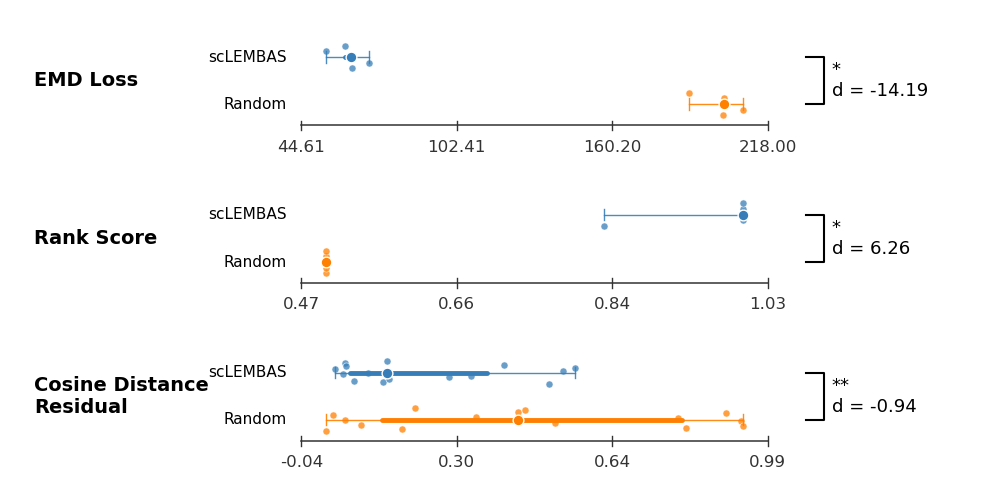

(<Figure size 1000x500 with 1 Axes>, <Axes: >)

In [83]:
metric_specs = [
    {'name': 'EMD Loss',            'actual': emd_actual,  'random': emd_random,
     'alternative': 'less'},
    {'name': 'Rank Score',          'actual': rank_actual, 'random': rank_random,
     'alternative': 'greater'},
    {'name': 'Cosine Distance\nResidual', 'actual': geo_actual,  'random': geo_random,
     'alternative': 'two-sided'},
]

compact_metric_summary(
    metric_specs,
    fig_name=os.path.join(data_path, 'figures','{}_predictive_performance_summary'.format(author)),
    show_fig=True,
)

In [13]:
# # ============================================================================
# # BLOCK 2 (ALTERNATIVE) -- standard box plots + scatter points
# #   Drop-in replacement for the compact_metric_summary version, keeping the
# #   original layout: one metric per row, panels STACKED VERTICALLY, each on
# #   its own native x-scale. Within a row the two models (Actual vs Random)
# #   are horizontal box plots with individual observations overlaid as a strip.
# #   A vertical significance bracket annotated with Wilcoxon stars + paired
# #   Cohen's d reproduces exactly what the original three panels computed.
# #
# #   NOTE on interpretation:
# #     - EMD and Rank are per-fold (n=5). A box over 5 points is fragile;
# #       the strip points carry the real signal there. Shown for side-by-side
# #       comparison, but points-only may be preferable for n=5.
# #     - Cosine residual is per-perturbation (dense) -> box + strip is ideal.
# # ============================================================================
# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy import stats


# def cohens_d_paired(a, b):
#     """Paired Cohen's d. Positive d => mean(a) > mean(b)."""
#     diff = np.asarray(a, float) - np.asarray(b, float)
#     return diff.mean() / diff.std(ddof=1)


# def _sig_stars(p):
#     if p <= 0.001:
#         return "***"
#     elif p <= 0.01:
#         return "**"
#     elif p <= 0.05:
#         return "*"
#     else:
#         return "ns"


# def boxplot_scatter_summary(
#     metric_specs,
#     model_order=("scLEMBAS", "Random"),
#     model_colors=None,
#     fig_name=None,
#     show_fig=True,
#     figsize=(9, 6.5),
#     point_size=5,
#     jitter=0.12,
#     seed=0,
# ):
#     """
#     metric_specs : list of dicts (top -> bottom), each with:
#         name        : str   -- metric label (native units kept)
#         actual      : 1d array of per-observation values for the model
#         random      : 1d array, PAIRED with `actual` (same length / order)
#         alternative : "less" | "greater" | "two-sided"  (Wilcoxon, actual vs random)
#         (optional) tick_fmt : per-metric x-tick format override
#     """
#     if model_colors is None:
#         set1 = sns.color_palette("Set1")
#         model_colors = {model_order[0]: set1[1], model_order[1]: set1[4]}
#     palette = {model_order[0]: model_colors[model_order[0]],
#                model_order[1]: model_colors[model_order[1]]}

#     n = len(metric_specs)
#     fig, axes = plt.subplots(n, 1, figsize=figsize)
#     if n == 1:
#         axes = [axes]

#     for ax, spec in zip(axes, metric_specs):
#         name = spec["name"]
#         a = np.asarray(spec["actual"], float)
#         b = np.asarray(spec["random"], float)
#         assert len(a) == len(b), \
#             "metric '{}': actual/random must be paired (equal length)".format(name)

#         # long-form frame for seaborn (horizontal orientation: value on x, model on y)
#         df = pd.DataFrame({
#             "value": np.concatenate([a, b]),
#             "model": ([model_order[0]] * len(a)) + ([model_order[1]] * len(b)),
#         })
#         df["model"] = pd.Categorical(df["model"], categories=list(model_order),
#                                      ordered=True)

#         sns.boxplot(
#             data=df, y="model", x="value", order=list(model_order), orient="h",
#             hue="model", hue_order=list(model_order), palette=palette,
#             width=0.55, fliersize=0, linewidth=1.2, ax=ax,
#             boxprops=dict(alpha=0.35), legend=False,
#         )
#         sns.stripplot(
#             data=df, y="model", x="value", order=list(model_order), orient="h",
#             hue="model", hue_order=list(model_order), palette=palette,
#             size=point_size, jitter=jitter, alpha=0.8,
#             edgecolor="white", linewidth=0.4, ax=ax, legend=False,
#         )

#         # significance test + paired Cohen's d
#         p = stats.wilcoxon(a, b, alternative=spec["alternative"]).pvalue
#         d = cohens_d_paired(a, b)

#         # vertical bracket spanning the two model rows (y=0 top, y=1 bottom),
#         # opening to the right just past the data
#         xmin = df["value"].min()
#         xmax = df["value"].max()
#         rng_ = xmax - xmin if xmax > xmin else (abs(xmax) + 1e-9)
#         x_tip = xmax + 0.04 * rng_
#         x_br = xmax + 0.09 * rng_
#         ax.plot([x_tip, x_br, x_br, x_tip], [0, 0, 1, 1],
#                 lw=1.3, c="black", clip_on=False)
#         ax.text(x_br + 0.02 * rng_, 0.5,
#                 "{}\nd = {:.2f}".format(_sig_stars(p), d),
#                 ha="left", va="center", fontsize=12, clip_on=False)
#         ax.set_xlim(xmin - 0.08 * rng_, x_br + 0.28 * rng_)

#         fmt = spec.get("tick_fmt")
#         if fmt is not None:
#             ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _p, f=fmt: f.format(v)))

#         ax.set_ylabel(name.replace("\n", " "), fontsize=13, fontweight="bold",
#                       rotation=0, ha="right", va="center", labelpad=18)
#         ax.set_xlabel("")
#         ax.tick_params(axis="y", labelsize=11)
#         ax.tick_params(axis="x", labelsize=10)
#         sns.despine(ax=ax, left=True)

#     plt.tight_layout()
#     if fig_name is not None:
#         stem = os.path.splitext(fig_name)[0]
#         fig.savefig(stem + ".png", dpi=600, bbox_inches="tight", transparent=True)
#     if show_fig:
#         plt.show()
#     return fig, axes



# metric_specs = [
#     {'name': 'EMD Loss',                  'actual': emd_actual,  'random': emd_random,
#      'alternative': 'less'},
#     {'name': 'Rank Score',                'actual': rank_actual, 'random': rank_random,
#      'alternative': 'greater'},
#     {'name': 'Cosine Distance\nResidual', 'actual': geo_actual,  'random': geo_random,
#      'alternative': 'two-sided'},
# ]

# boxplot_scatter_summary(
#     metric_specs,
#     fig_name=None, #os.path.join(data_path, 'figures','{}_predictive_performance_summary_boxplot'.format(author)),
#     show_fig=True,
# )

Cosine distance line plot:

In [21]:
def pert_centroids(adata):
    X = adata.to_df()
    X[pert_col] = adata.obs[pert_col].astype(str).tolist()
    X = X.groupby(pert_col).mean()
    return X


def get_cos_dist(fold, tf_adata_merged):
    distances = defaultdict(list)

    split = get_split(fold, author)
    test_conds = split['test_conds']
    ctrl_conds = list({'^'.join([tc.split('^')[0], ctrl_pert]) for tc in test_conds})

    cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata_merged[cond_mask, :].copy()
    predicted_mask = (tf_adata_test.obs.batch == 'predicted')

    tf_adata_predicted = tf_adata_test[predicted_mask, :].copy()  # predicted test conditions only
    tf_adata_actual_pert = tf_adata[tf_adata.obs.condition.isin(test_conds), :]  # actual data
    tf_adata_actual_ctrl = tf_adata[tf_adata.obs.condition.isin(ctrl_conds), :]  # corresponding controls

    X_pred = pert_centroids(tf_adata_predicted)
    X_actual_pert = pert_centroids(tf_adata_actual_pert)
    assert sorted(X_pred.index) == sorted(X_actual_pert.index), 'Test conditions are not consistent'

    all_pert_centroid = tf_adata_actual_pert.to_df().mean(axis=0).values
    ctrl_centroid = pert_centroids(tf_adata_actual_ctrl).values[0]

    X_pred = X_pred.loc[X_actual_pert.index, :].copy()

    for pert in X_pred.index:
        actual_pert_centroid = X_actual_pert.loc[pert, :].values
        pred_pert_centroid = X_pred.loc[pert, :].values

        v_actual_pert = actual_pert_centroid - ctrl_centroid
        v_ctrl = all_pert_centroid - ctrl_centroid
        cos_dist_actual = cosine_distance(v_actual_pert, v_ctrl)

        v_pred_pert = pred_pert_centroid - ctrl_centroid
        cos_dist_pred = cosine_distance(v_pred_pert, v_ctrl)

        distances['fold'].append(fold)
        distances['perturbation'].append(pert)
        distances['actual'].append(cos_dist_actual)
        distances['predicted'].append(cos_dist_pred)

    return pd.DataFrame(distances)


cos_distances = []
for fold in trange(n_folds):
    key = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas[key].copy()

    cos_distances_fold = get_cos_dist(fold, tf_adata_merged)
    cos_distances.append(cos_distances_fold)

cos_distances = pd.concat(cos_distances, ignore_index=True)
cos_distances['mod_type'] = 'actual'

cos_distances_rand = []
for fold in trange(n_folds):
    key = 'none_{}'.format(fold)
    tf_adata_merged = merged_adatas_rand[key].copy()

    distnances_fold = get_cos_dist(fold, tf_adata_merged)
    cos_distances_rand.append(distnances_fold)

cos_distances_rand = pd.concat(cos_distances_rand, ignore_index=True)
cos_distances_rand['mod_type'] = 'random'

cos_distances = pd.concat([cos_distances, cos_distances_rand], ignore_index=True)
cos_distances.mod_type = pd.Categorical(
    cos_distances.mod_type,
    categories=['actual', 'random'],
    ordered=True
)




100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 27.96it/s]


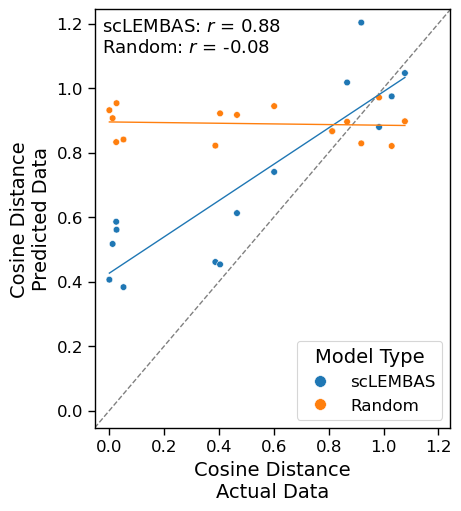

In [81]:
with sns.plotting_context(
    "paper",
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
):

    fig, ax = plt.subplots(figsize=(4.5,5), constrained_layout=True)

    sns.scatterplot(data=cos_distances, x='actual', y='predicted', hue='mod_type', ax=ax, zorder=2)

    for mod_type in ['actual', 'random']:
        viz_df = cos_distances[cos_distances.mod_type == mod_type].copy()

        sns.regplot(
            data=viz_df,
            x="actual",
            y="predicted",
            ax=ax,
            scatter=False,
            ci=None,
            line_kws={"linewidth": 1},
        )

    # pearson
    pr_actual = stats.pearsonr(cos_distances[cos_distances.mod_type == 'actual'].actual,
                               cos_distances[cos_distances.mod_type == 'actual'].predicted).statistic
    pr_noadv = stats.pearsonr(cos_distances[cos_distances.mod_type == 'random'].actual,
                              cos_distances[cos_distances.mod_type == 'random'].predicted).statistic

    ax.text(
        0.02, 0.98,
        "scLEMBAS: $r$ = {:.2f}\nRandom: $r$ = {:.2f}".format(pr_actual, pr_noadv),
#         "{}: Pearson = {:.2f}\n{}: Pearson = {:.2f}".format('Actual', pr_actual, 'Random', pr_noadv),
        transform=ax.transAxes,
        ha="left", va="top", 
        fontsize = 13
    )

    ax.set_xlabel('Cosine Distance\nActual Data')
    ax.set_ylabel('Cosine Distance\nPredicted Data')

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    ax_min = min(xmin, ymin)
    ax_max = max(xmax, ymax)

    ax.set_xlim(ax_min, ax_max)
    ax.set_ylim(ax_min, ax_max)

    ax.plot(
        [ax_min, ax_max],
        [ax_min, ax_max],
        linestyle="--",
        color="gray",
        linewidth=1,
        zorder=0
    )

    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles, labels=['scLEMBAS', 'Random'], title='Model Type',
        loc="lower right",
        title_fontsize=14, markerscale = 1.75,
        frameon=True
    )
    
    fig.savefig(os.path.join(data_path, 'figures', '{}_cos_distance_figure.png'.format(author)), 
                dpi=600, bbox_inches='tight')


# Individual component violin plots:

In [ ]:
# #!/usr/bin/env python
# # coding: utf-8

# # %% Load predictions
# merged_adatas = io.read_pickled_object(
#     os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
# )
# for v in merged_adatas.values():
#     v.obs_names_make_unique()


# # %% Helper: load actual / predicted test data for a fold + ablation key
# def load_test_tfadata(fold, key):
#     key_ = '{}_{}'.format(key, fold)
#     tf_adata_merged = merged_adatas[key_].copy()

#     split = get_split(fold, author)
#     test_conds = split['test_conds']

#     test_cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
#     tf_adata_test = tf_adata_merged[test_cond_mask, :].copy()
#     assert 'predicted_ctrl' not in tf_adata_test.obs.batch, 'Unexpected training predictions present'

#     predicted_mask = (tf_adata_test.obs.batch == 'predicted')
#     tf_adata_predicted = tf_adata_test[predicted_mask, :].copy()
#     tf_adata_actual = tf_adata_test[~predicted_mask, :].copy()
#     assert len(np.where(tf_adata.obs.condition.isin(test_conds))[0]) == tf_adata_actual.shape[0], 'Incorrect subsetting of actual data'

#     return tf_adata_actual, tf_adata_predicted


# # %% Define ablations and display labels
# remove_types = [
#     'none',
#     ['adj', 'categorical_bias'],
#     ['adj', 'global_bias'],
#     'total_bias',
#     'adj',
#     'categorical_bias',
#     'global_bias',
# ]
# remove_types = [rt if type(rt) != list else '^'.join(rt) for rt in remove_types]

# ablated_components = {
#     'none': 'None',
#     'global_bias': 'Global Bias',
#     'adj^global_bias': 'Adj + Global Bias',
#     'total_bias': 'Total Bias',
#     'adj^categorical_bias': 'Adj + Categorical Bias',
#     'adj': 'Adjaceny Matrix Only',
#     'categorical_bias': 'Categorical Bias Only',
# }
# remaining_components = {
#     'none': 'Full Model',
#     'global_bias': 'Adj + Categorical Bias',
#     'adj^global_bias': 'Categorical Bias Only',
#     'total_bias': 'Adjaceny Matrix Only',
#     'adj^categorical_bias': 'Global Bias Only',
#     'adj': 'Total Bias',
#     'categorical_bias': 'Adj + Global Bias',
# }

# ar_c = {}
# for k, v in ablated_components.items():
#     ar_c[k] = '{}\n({})'.format(ablated_components[k], remaining_components[k])


# # %% Compute EMD loss per component (full feature space only)
# loss_dict = defaultdict(list)

# for (fold, key) in itertools.product(range(5), remove_types):
#     tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold, key)

#     emd_loss = distances.get_EMD_loss(
#         tf_adata_actual, tf_adata_predicted,
#         groupby_col='condition',  # per test condition
#         latent_models=None,
#     )['Mean EMD Loss']

#     loss_dict['Mean EMD Loss'].append(emd_loss)
#     loss_dict['Fold'].append(fold + 1)
#     loss_dict['Model Components'].append(key)

# emd_loss = pd.DataFrame(loss_dict)

# # Normalize each fold's losses by that fold's full-model ('none') loss
# baseline = (
#     emd_loss[emd_loss['Model Components'] == 'none']
#     .set_index('Fold')['Mean EMD Loss']
# )
# emd_loss['Normalized Mean EMD Loss'] = (
#     emd_loss['Mean EMD Loss'] / emd_loss['Fold'].map(baseline)
# )

# emd_loss.to_csv(os.path.join(data_path, 'processed', '{}_emd_loss_per_component.csv'.format(author)))


# # %% Reload and order categories for plotting
# emd_loss = pd.read_csv(
#     os.path.join(data_path, 'processed', '{}_emd_loss_per_component.csv'.format(author)),
#     index_col=0,
# )

# emd_loss['Model Components'] = pd.Categorical(
#     emd_loss['Model Components'].map(ar_c),
#     ordered=True,
#     categories=list(ar_c.values()),
# )

In [ ]:
# # %% Visualization
# def component_dist_viz(fig_name=None, show_fig=True):
#     fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)

#     # Drop the unablated full model ('none') from the violins
#     viz_df = emd_loss.copy()
#     viz_df['Model Components'] = (
#         viz_df['Model Components'][~viz_df['Model Components'].isin([ar_c['none']])]
#         .cat.remove_unused_categories()
#     )
#     viz_df = viz_df[viz_df['Model Components'].notna()].copy()

#     sns.violinplot(data=viz_df, x='Model Components', y='Normalized Mean EMD Loss', ax=ax)

#     ax.axhline(y=0, color="black", label="Perfect Prediction")
#     ax.axhline(y=1, color="red", linestyle="--", label="Normalized Full Model Loss")
#     ax.legend(loc="lower center", bbox_to_anchor=(0.5, 0.1))

#     ax.tick_params(axis="x", rotation=45)
#     for label in ax.get_xticklabels():
#         label.set_ha("right")
#     ax.set_xlabel('Ablated Model Component(s)')

#     if fig_name is not None:
#         dirpath = os.path.dirname(fig_name)
#         basename = os.path.basename(fig_name)
#         stem, _ = os.path.splitext(basename)
#         out_base = os.path.join(dirpath, stem)
#         print("{}.png".format(out_base))
#         plt.savefig("{}.png".format(out_base), dpi=600, bbox_inches="tight", transparent=True)

#     if show_fig:
#         plt.show()



In [ ]:
# with sns.plotting_context(
#     "paper",
#     rc={
#         "axes.labelsize": 14,
#         "axes.titlesize": 16,
#         "legend.fontsize": 12,
#         "xtick.labelsize": 12,
#         "ytick.labelsize": 12,
#     }
# ):

#     component_dist_viz(
#         fig_name=os.path.join(data_path, 'figures','{}_per_component_loss_distributions_figure.png'.format(author)),
#         show_fig=True,
#     )